In [294]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

In [295]:
def equ(x, a, b): return a * np.exp(-b * x)
def equ2(x, a, b): return a / (x**b)

In [296]:
x = np.linspace(0, 2*np.pi, 100)
a = 5
b = 0.5

y = equ(x, a, b)

In [297]:
sigma = np.linspace(2, 0.2, 100)

noise = np.random.normal(0, sigma)

y_scattered = y + noise


First Model: a = 5.862, b = 0.489
Second Model: a = 2.432, b = 0.410


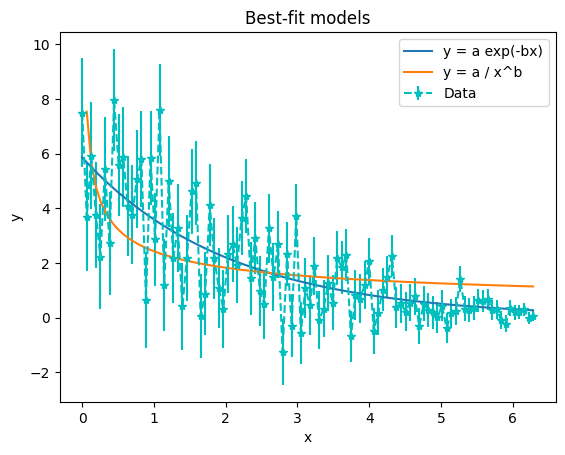

In [298]:
params1, cov1 = curve_fit(equ, x, y_scattered)
params2, cov2 = curve_fit(equ2, x[1:], y_scattered[1:])

a1, b1 = params1
a2, b2 = params2

print(f'First Model: a = {a1:.3f}, b = {b1:.3f}')
print(f'Second Model: a = {a2:.3f}, b = {b2:.3f}')

y_fit1 = equ(x, a1, b1)
y_fit2 = equ2(x[1:], a2, b2)

plt.errorbar(
    x,
    y_scattered,
    yerr=sigma,
    fmt='c*--',
    label='Data'
)

plt.plot(x, y_fit1, label='y = a exp(-bx)')
plt.plot(x[1:], y_fit2, label='y = a / x^b')

plt.xlabel("x")
plt.ylabel("y")
plt.title("Best-fit models")
plt.legend()

plt.savefig("Journal2-Part3.pdf")
plt.show()